===== DADOS DE VENDAS =====
    id_venda  data_venda    produto    categoria  valor_venda
0          1  2023-01-01  Produto A  Eletrônicos       1500.0
1          2  2023-01-05  Produto B       Roupas        350.0
2          3  2023-02-10  Produto C  Eletrônicos       1200.0
3          4  2023-03-15  Produto D       Livros        200.0
4          5  2023-03-20  Produto E  Eletrônicos        800.0
5          6  2023-04-02  Produto F       Roupas        400.0
6          7  2023-05-05  Produto G       Livros        150.0
7          8  2023-06-10  Produto H  Eletrônicos       1000.0
8          9  2023-07-20  Produto I       Roupas        600.0
9         10  2023-08-25  Produto J  Eletrônicos        700.0
10        11  2023-09-30  Produto K       Livros        300.0
11        12  2023-10-05  Produto L       Roupas        450.0
12        13  2023-11-15  Produto M  Eletrônicos        900.0
13        14  2023-12-20  Produto N       Livros        250.0

===== TOTAL DE VENDAS POR CATEGORIA =====

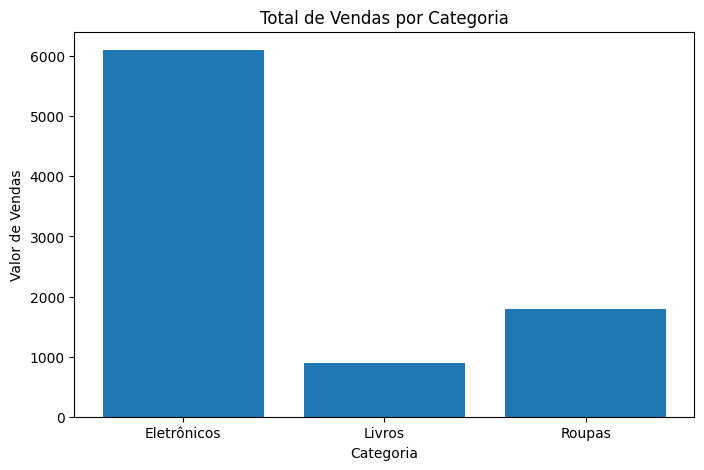

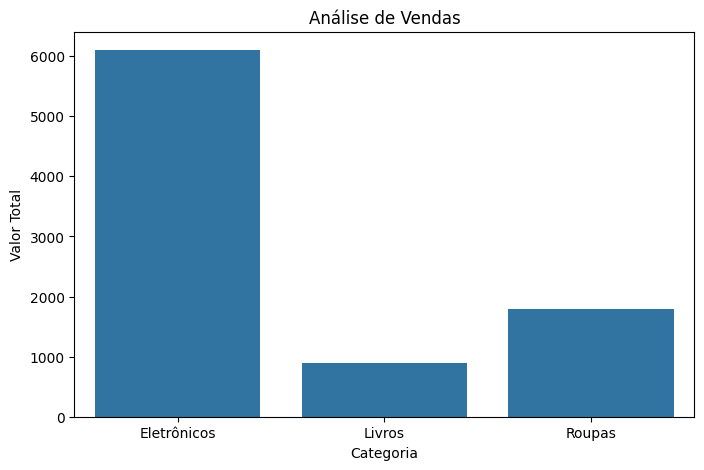

In [6]:
# Importando bibliotecas
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conectando ao banco de dados SQLite
conexao = sqlite3.connect('dados_vendas.db')

# Criando cursor
cursor = conexao.cursor()

# Criando tabela
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

# Limpando tabela para evitar dados duplicados
cursor.execute("DELETE FROM vendas1")

# Inserindo dados na tabela
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00)
''')

# Salvando alterações no banco
conexao.commit()

# Lendo os dados com Pandas
df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

# Exibindo os dados
print("===== DADOS DE VENDAS =====")
print(df_vendas)

# Agrupando vendas por categoria
vendas_categoria = df_vendas.groupby("categoria")["valor_venda"].sum()

# Exibindo análise
print("\n===== TOTAL DE VENDAS POR CATEGORIA =====")
print(vendas_categoria)

# Gráfico com Matplotlib
plt.figure(figsize=(8,5))
plt.bar(vendas_categoria.index, vendas_categoria.values)

plt.title("Total de Vendas por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Valor de Vendas")

plt.show()

# Gráfico com Seaborn
plt.figure(figsize=(8,5))
sns.barplot(x=vendas_categoria.index, y=vendas_categoria.values)

plt.title("Análise de Vendas")
plt.xlabel("Categoria")
plt.ylabel("Valor Total")

plt.show()

# Encerrando conexão
conexao.close()
